In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/content/drive/MyDrive/dataset_blood_group'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Streaming output truncated to the last 5000 lines.
/content/drive/MyDrive/dataset_blood_group/B+/cluster_2_2722 - Copy.BMP
/content/drive/MyDrive/dataset_blood_group/B+/cluster_2_1840.BMP
/content/drive/MyDrive/dataset_blood_group/B+/cluster_2_2001 - Copy.BMP
/content/drive/MyDrive/dataset_blood_group/B+/cluster_2_1942 - Copy.BMP
/content/drive/MyDrive/dataset_blood_group/B+/cluster_2_1256.BMP
/content/drive/MyDrive/dataset_blood_group/B+/cluster_2_2397 - Copy.BMP
/content/drive/MyDrive/dataset_blood_group/B+/cluster_2_2004.BMP
/content/drive/MyDrive/dataset_blood_group/B+/cluster_2_1150 - Copy.BMP
/content/drive/MyDrive/dataset_blood_group/B+/cluster_2_1601 - Copy.BMP
/content/drive/MyDrive/dataset_blood_group/B+/cluster_2_2205 - Copy.BMP
/content/drive/MyDrive/dataset_blood_group/B+/cluster_2_1911.BMP
/content/drive/MyDrive/dataset_blood_group/B+/cluster_2_1533.BMP
/content/drive/MyDrive/dataset_blood_group/B+/cluster_2_2264.BMP
/content/drive/MyDrive/dataset_blood_group/B+/cluster_2

In [ ]:
# Install required packages
!pip install transformers pillow torch --quiet

# ---------------------------
# 1. Mount Google Drive
# ---------------------------
from google.colab import drive
drive.mount('/content/drive')

import os
import torch
import numpy as np
from PIL import Image
from transformers import BeitFeatureExtractor, BeitModel
from tqdm import tqdm

# ---------------------------
# 2. Load BEiT Feature Extractor & Model
# ---------------------------
print("Loading BEiT model...")
feature_extractor = BeitFeatureExtractor.from_pretrained("microsoft/beit-base-patch16-224")
model = BeitModel.from_pretrained("microsoft/beit-base-patch16-224")
model.eval()
print("Model loaded successfully!")

# ---------------------------
# 3. Dataset path and verification
# ---------------------------
dataset_path = "/content/drive/MyDrive/dataset_blood_group"

# Check if path exists
if not os.path.exists(dataset_path):
    print(f"❌ Dataset path does not exist: {dataset_path}")
    print("Available directories in /content/drive/MyDrive/:")
    if os.path.exists("/content/drive/MyDrive/"):
        for item in os.listdir("/content/drive/MyDrive/"):
            print(f"  - {item}")
    else:
        print("Google Drive not properly mounted!")
else:
    print(f"✅ Dataset path exists: {dataset_path}")

# List directory contents to debug
print(f"\nContents of {dataset_path}:")
if os.path.exists(dataset_path):
    for item in os.listdir(dataset_path):
        item_path = os.path.join(dataset_path, item)
        if os.path.isdir(item_path):
            print(f"  📁 {item}/ ({len(os.listdir(item_path))} items)")
        else:
            print(f"  📄 {item}")

# ---------------------------
# 4. Recursive image search (FIXED)
# ---------------------------
print("\nSearching for images...")
image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp")

image_files = []
labels = []  # To store folder names as labels

if os.path.exists(dataset_path):
    for root, dirs, files in os.walk(dataset_path):  # FIXED: removed the typo
        for file in files:
            if file.lower().endswith(image_extensions):
                img_path = os.path.join(root, file)
                image_files.append(img_path)

                # Extract label from folder structure
                relative_path = os.path.relpath(root, dataset_path)
                if relative_path == '.':
                    label = 'unlabeled'
                else:
                    label = relative_path.split(os.sep)[0]  # First folder name
                labels.append(label)

print(f"Found {len(image_files)} images.")

# Show distribution of labels
if labels:
    from collections import Counter
    label_counts = Counter(labels)
    print("\nLabel distribution:")
    for label, count in label_counts.items():
        print(f"  {label}: {count} images")

# ---------------------------
# 5. Process images with BEiT (with progress bar)
# ---------------------------
if len(image_files) == 0:
    print("❌ No images found! Please check:")
    print("1. The dataset path is correct")
    print("2. Images have valid extensions:", image_extensions)
    print("3. Google Drive is properly mounted")
else:
    print(f"\nProcessing {len(image_files)} images...")

    all_features = []
    processed_files = []
    processed_labels = []

    for i, img_path in enumerate(tqdm(image_files, desc="Processing images")):
        try:
            # Open and verify image
            image = Image.open(img_path).convert("RGB")

            # Check image size
            if image.size[0] < 10 or image.size[1] < 10:
                print(f"⚠️ Skipping very small image: {os.path.basename(img_path)}")
                continue

            # Preprocess
            inputs = feature_extractor(images=image, return_tensors="pt")

            # Extract features
            with torch.no_grad():
                outputs = model(**inputs)
                pooled_output = outputs.pooler_output  # Shape: [1, hidden_size]

            # Save pooled feature vector
            all_features.append(pooled_output.squeeze().numpy())
            processed_files.append(img_path)
            processed_labels.append(labels[i])

            if (i + 1) % 50 == 0:  # Progress update every 50 images
                print(f"Processed {i + 1}/{len(image_files)} images")

        except Exception as e:
            print(f"❌ Error processing {os.path.basename(img_path)}: {e}")

    # ---------------------------
    # 6. Save results
    # ---------------------------
    if all_features:
        features_array = np.array(all_features)
        print(f"\n✅ Successfully processed {len(all_features)} images")
        print(f"Final feature tensor shape: {features_array.shape}")

        # Save features
        np.save("/content/drive/MyDrive/blood_group_features.npy", features_array)
        print("✅ Features saved to: /content/drive/MyDrive/blood_group_features.npy")

        # Save labels
        np.save("/content/drive/MyDrive/blood_group_labels.npy", np.array(processed_labels))
        print("✅ Labels saved to: /content/drive/MyDrive/blood_group_labels.npy")

        # Save file paths for reference
        with open("/content/drive/MyDrive/blood_group_file_paths.txt", "w") as f:
            for file_path in processed_files:
                f.write(file_path + "\n")
        print("✅ File paths saved to: /content/drive/MyDrive/blood_group_file_paths.txt")

        # Summary
        print(f"\n📊 Processing Summary:")
        print(f"  - Total images found: {len(image_files)}")
        print(f"  - Successfully processed: {len(all_features)}")
        print(f"  - Feature dimension: {features_array.shape[1]}")
        print(f"  - Unique labels: {len(set(processed_labels))}")

    else:
        print("❌ No features extracted. Check dataset path or file types.")

# ---------------------------
# 7. Quick verification of saved files
# ---------------------------
print("\n" + "="*50)
print("VERIFICATION")
print("="*50)

files_to_check = [
    "/content/drive/MyDrive/blood_group_features.npy",
    "/content/drive/MyDrive/blood_group_labels.npy",
    "/content/drive/MyDrive/blood_group_file_paths.txt"
]

for file_path in files_to_check:
    if os.path.exists(file_path):
        if file_path.endswith('.npy'):
            data = np.load(file_path)
            print(f"✅ {os.path.basename(file_path)}: shape {data.shape}")
        else:
            with open(file_path, 'r') as f:
                lines = f.readlines()
            print(f"✅ {os.path.basename(file_path)}: {len(lines)} entries")
    else:
        print(f"❌ {os.path.basename(file_path)}: not found")

print("\n🎉 Feature extraction complete!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading BEiT model...
Model loaded successfully!
✅ Dataset path exists: /content/drive/MyDrive/dataset_blood_group

Contents of /content/drive/MyDrive/dataset_blood_group:
  📁 O+/ (1352 items)
  📁 A-/ (1009 items)
  📁 B-/ (1311 items)
  📁 B+/ (1272 items)
  📁 AB-/ (1481 items)
  📁 AB+/ (1124 items)
  📁 O-/ (1162 items)
  📁 A+/ (1130 items)

Searching for images...
Found 9841 images.

Label distribution:
  O+: 1352 images
  A-: 1009 images
  B-: 1311 images
  B+: 1272 images
  AB-: 1481 images
  AB+: 1124 images
  O-: 1162 images
  A+: 1130 images

Processing 9841 images...


Processing images:   1%|          | 50/9841 [01:13<2:11:22,  1.24it/s]

Processed 50/9841 images


Processing images:   1%|          | 100/9841 [02:02<2:03:30,  1.31it/s]

Processed 100/9841 images


...

Processed 9750/9841 images


Processing images: 100%|█████████▉| 9800/9841 [2:35:56<00:45,  1.11s/it]

Processed 9800/9841 images


Processing images: 100%|██████████| 9841/9841 [2:36:39<00:00,  1.05it/s]



✅ Successfully processed 9841 images
Final feature tensor shape: (9841, 768)
✅ Features saved to: /content/drive/MyDrive/blood_group_features.npy
✅ Labels saved to: /content/drive/MyDrive/blood_group_labels.npy
✅ File paths saved to: /content/drive/MyDrive/blood_group_file_paths.txt

📊 Processing Summary:
  - Total images found: 9841
  - Successfully processed: 9841
  - Feature dimension: 768
  - Unique labels: 8

VERIFICATION
✅ blood_group_features.npy: shape (9841, 768)
✅ blood_group_labels.npy: shape (9841,)
✅ blood_group_file_paths.txt: 9841 entries

🎉 Feature extraction complete!


Found 7876 images belonging to 8 classes.
Found 1965 images belonging to 8 classes.
Epoch 1/60
247/247 ━━━━━━━━━━━━━━━━━━━━ 39s 142ms/step - accuracy: 0.2087 - loss: 3.1542 - val_accuracy: 0.5125 - val_loss: 1.4868
Epoch 2/60
247/247 ━━━━━━━━━━━━━━━━━━━━ 27s 110ms/step - accuracy: 0.5170 - loss: 1.4375 - val_accuracy: 0.7094 - val_loss: 0.9865
Epoch 3/60
247/247 ━━━━━━━━━━━━━━━━━━━━ 28s 115ms/step - accuracy: 0.6946 - loss: 1.0151 - val_accuracy: 0.7756 - val_loss: 0.7754
Epoch 4/60
247/247 ━━━━━━━━━━━━━━━━━━━━ 28s 113ms/step - accuracy: 0.7392 - loss: 0.8625 - val_accuracy: 0.7868 - val_loss: 0.7186
Epoch 5/60
247/247 ━━━━━━━━━━━━━━━━━━━━ 28s 112ms/step - accuracy: 0.7682 - loss: 0.7917 - val_accuracy: 0.8031 - val_loss: 0.6689
Epoch 6/60
247/247 ━━━━━━━━━━━━━━━━━━━━ 28s 113ms/step - accuracy: 0.7800 - loss: 0.7314 - val_accuracy: 0.8224 - val_loss: 0.6163
Epoch 7/60
247/247 ━━━━━━━━━━━━━━━━━━━━ 28s 113ms/step - accuracy: 0.7975 - loss: 0.6804 - val_accuracy: 0.8407 - val_loss: 0.5909

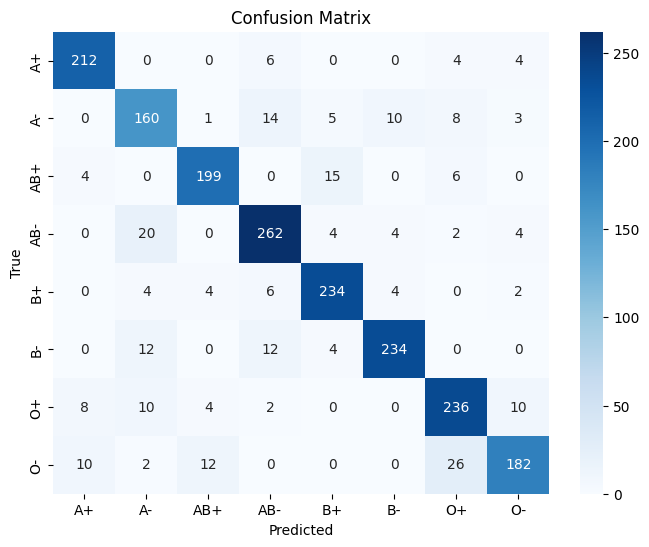

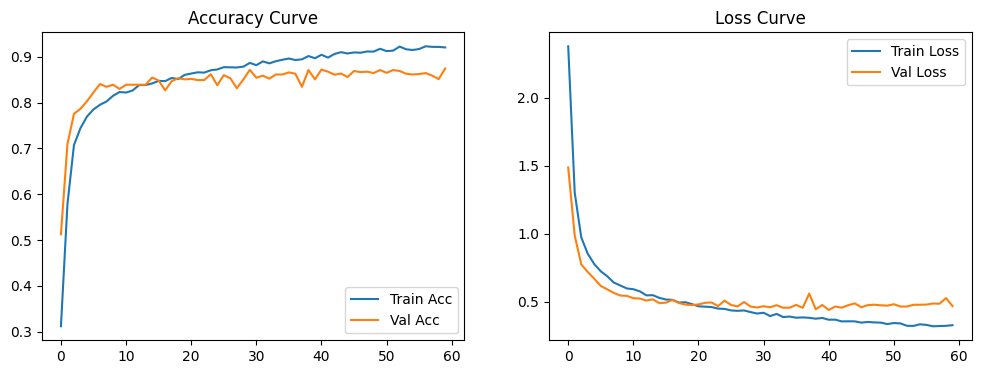

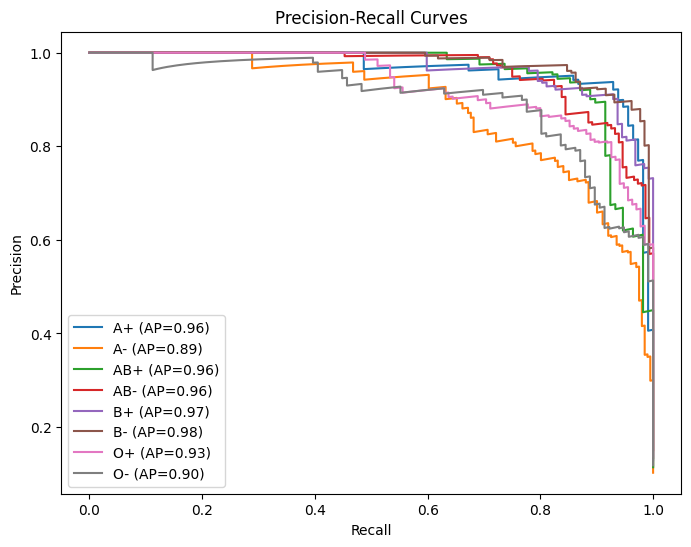

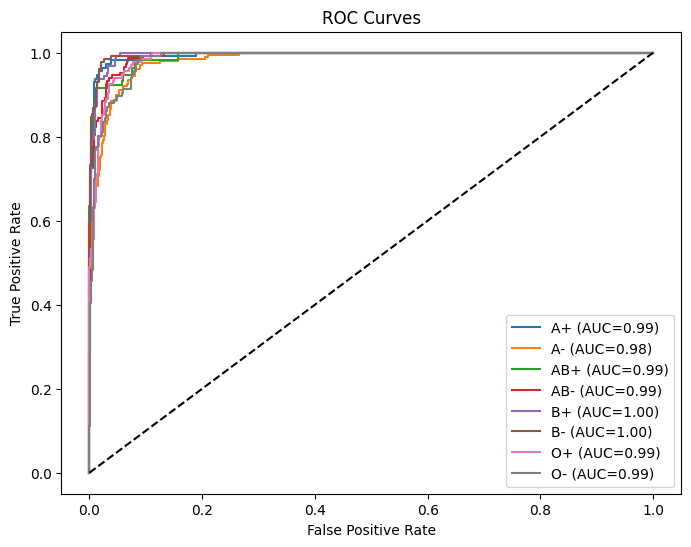

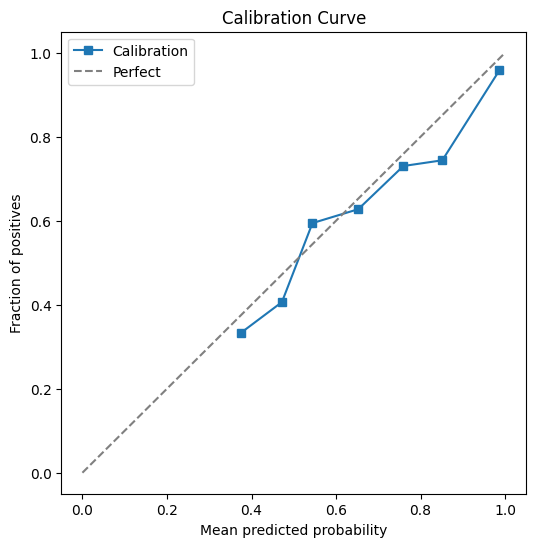

Brier Score: 0.0899
Total misclassified samples: 246


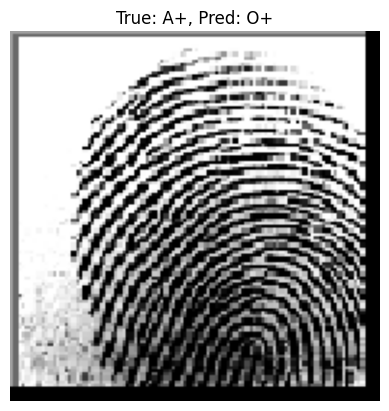

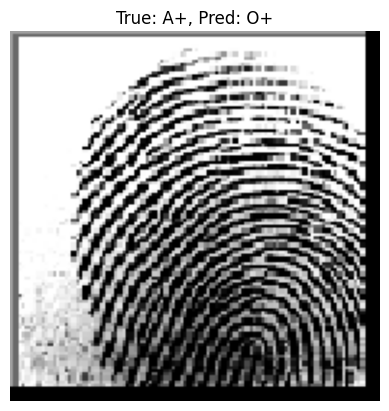

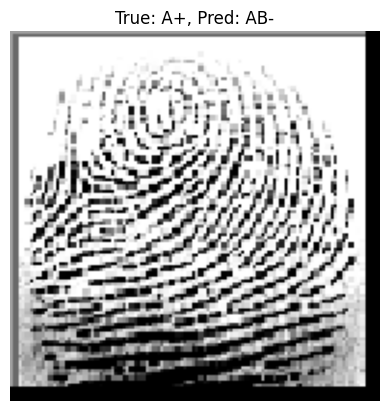

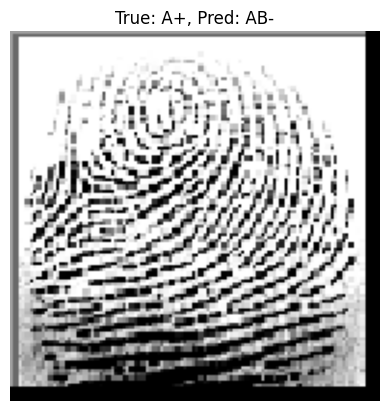

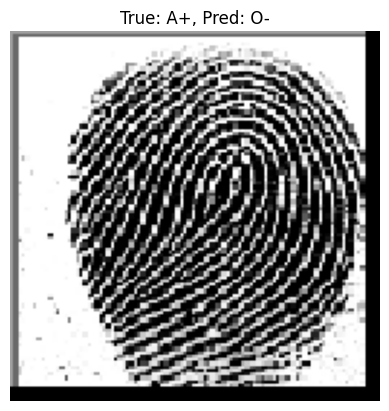

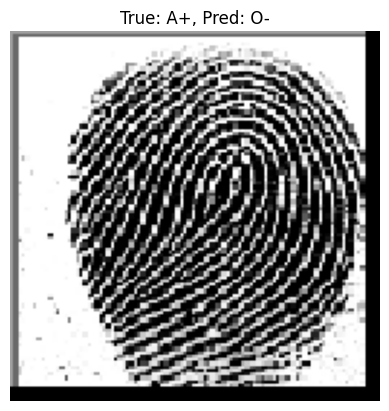

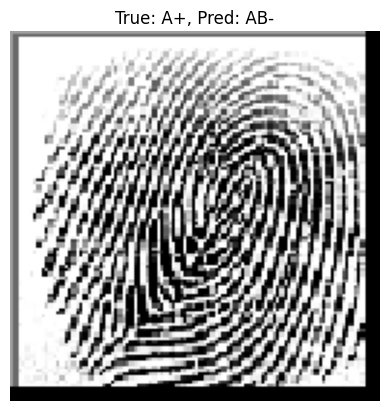

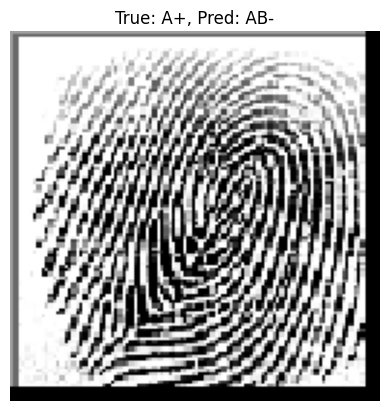

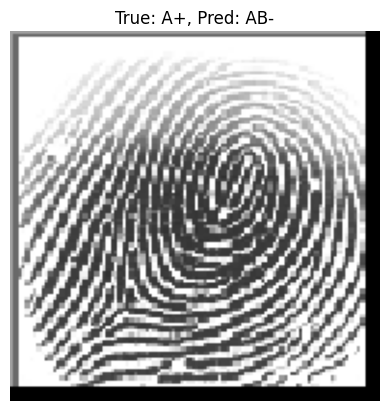

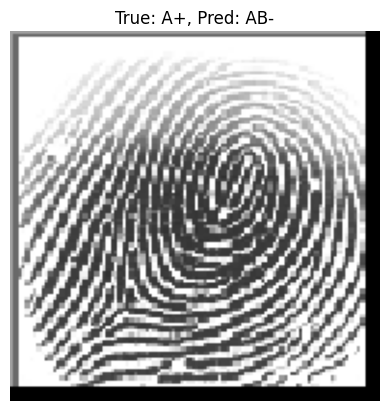

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers, regularizers
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_curve, average_precision_score,
                             roc_curve, auc, brier_score_loss)
from sklearn.calibration import calibration_curve

# -------------------------
# Dataset Path
# -------------------------
dataset_path = "/content/drive/MyDrive/dataset_blood_group"

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
img_size = (128, 128)
batch_size = 32

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

# -------------------------
# Attention Layer
# -------------------------
class AttentionLayer(layers.Layer):
    def __init__(self):
        super(AttentionLayer, self).__init__()

    def call(self, inputs):
        attention_scores = tf.nn.softmax(tf.reduce_mean(inputs, axis=-1, keepdims=True), axis=1)
        return inputs * attention_scores

# -------------------------
# CNN + Attention Model
# -------------------------
def build_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation="relu", input_shape=input_shape),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation="relu"),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), activation="relu"),
        layers.MaxPooling2D((2,2)),

        AttentionLayer(),

        layers.Flatten(),
        layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(0.01)),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

num_classes = len(train_data.class_indices)
model = build_model((128,128,3), num_classes)

model.compile(optimizer=optimizers.Adam(1e-4),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# -------------------------
# Train
# -------------------------
history = model.fit(
    train_data,
    epochs=60,
    validation_data=val_data
)

# -------------------------
# Evaluation
# -------------------------
val_preds = model.predict(val_data)
y_pred = np.argmax(val_preds, axis=1)
y_true = val_data.classes
class_names = list(val_data.class_indices.keys())

# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Training Curves
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.legend()
plt.title("Accuracy Curve")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

# -------------------------
# Precision-Recall Curves
# -------------------------
plt.figure(figsize=(8,6))
for i, class_name in enumerate(class_names):
    precision, recall, _ = precision_recall_curve((y_true == i).astype(int), val_preds[:, i])
    ap = average_precision_score((y_true == i).astype(int), val_preds[:, i])
    plt.plot(recall, precision, label=f"{class_name} (AP={ap:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.show()

# -------------------------
# ROC Curves
# -------------------------
plt.figure(figsize=(8,6))
for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve((y_true == i).astype(int), val_preds[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC={roc_auc:.2f})")
plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

# -------------------------
# Calibration Curve + Brier Score
# -------------------------
probs_true = np.max(val_preds, axis=1)   # predicted confidence
y_binary = (y_true == y_pred).astype(int)
prob_true, prob_pred = calibration_curve(y_binary, probs_true, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, "s-", label="Calibration")
plt.plot([0,1], [0,1], "--", color="gray", label="Perfect")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration Curve")
plt.legend()
plt.show()

brier = brier_score_loss(y_binary, probs_true)
print(f"Brier Score: {brier:.4f}")

# -------------------------
# Misclassified Samples (Obligation Study)
# -------------------------
mis_idx = np.where(y_true != y_pred)[0]
print(f"Total misclassified samples: {len(mis_idx)}")

# Iterate through the misclassified indices and display each image individually
for i in mis_idx[:10]:  # show first 10
    # Get the batch index and index within the batch
    batch_index = i // val_data.batch_size
    index_in_batch = i % val_data.batch_size

    # Get the image and labels from the batch
    img_batch, label_batch = val_data[batch_index]
    img = img_batch[index_in_batch]
    true_label = y_true[i]
    pred_label = y_pred[i]

    plt.imshow(img)
    plt.title(f"True: {class_names[true_label]}, Pred: {class_names[pred_label]}")
    plt.axis("off")
    plt.show()

Found 7876 images belonging to 8 classes.
Found 1965 images belonging to 8 classes.
Number of classes: 8


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ channel_attention_layer         │ (None, 128, 128, 32)   │           292 │
│ (ChannelAttentionLayer)         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ channel_attention_layer_1       │ (None, 64, 64, 64)     │         1,096 │
│ (ChannelAttentionLayer)         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_attention_layer         │ (None, 32, 32, 128)    │            99 │
│ (SpatialAttentionLayer)         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_attention_layer_1       │ (None, 16, 16, 256)    │            99 │
│ (SpatialAttentionLayer)         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 8, 512)         │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,542,778 (5.89 MB)

 Trainable params: 1,541,818 (5.88 MB)

...

247/247 ━━━━━━━━━━━━━━━━━━━━ 51s 204ms/step - accuracy: 0.8894 - loss: 1.4962 - top_k_categorical_accuracy: 0.9993 - val_accuracy: 0.8020 - val_loss: 1.6391 - val_top_k_categorical_accuracy: 1.0000 - learning_rate: 1.0000e-04
Epoch 7/40
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.9068 - loss: 1.2658 - top_k_categorical_accuracy: 0.9998
Epoch 7: val_accuracy did not improve from 0.80204
247/247 ━━━━━━━━━━━━━━━━━━━━ 86s 222ms/step - accuracy: 0.9068 - loss: 1.2657 - top_k_categorical_accuracy: 0.9998 - val_accuracy: 0.7812 - val_loss: 1.5388 - val_top_k_categorical_accuracy: 0.9929 - learning_rate: 1.0000e-04
Epoch 8/40
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.9262 - loss: 1.0814 - top_k_categorical_accuracy: 1.0000
Epoch 8: val_accuracy did not improve from 0.80204
247/247 ━━━━━━━━━━━━━━━━━━━━ 51s 205ms/step - accuracy: 0.9262 - loss: 1.0813 - top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.7313 - val_loss: 1.7884 - val_top_k_categorical_accuracy: 0.986

247/247 ━━━━━━━━━━━━━━━━━━━━ 51s 206ms/step - accuracy: 0.9336 - loss: 0.9355 - top_k_categorical_accuracy: 0.9999 - val_accuracy: 0.8066 - val_loss: 1.2766 - val_top_k_categorical_accuracy: 0.9990 - learning_rate: 1.0000e-04
Epoch 10/40
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.9459 - loss: 0.8063 - top_k_categorical_accuracy: 0.9996
Epoch 10: val_accuracy did not improve from 0.80662
247/247 ━━━━━━━━━━━━━━━━━━━━ 50s 203ms/step - accuracy: 0.9459 - loss: 0.8062 - top_k_categorical_accuracy: 0.9996 - val_accuracy: 0.7420 - val_loss: 1.5048 - val_top_k_categorical_accuracy: 0.9908 - learning_rate: 1.0000e-04
Epoch 11/40
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.9530 - loss: 0.6951 - top_k_categorical_accuracy: 0.9996
Epoch 11: val_accuracy did not improve from 0.80662
247/247 ━━━━━━━━━━━━━━━━━━━━ 55s 221ms/step - accuracy: 0.9530 - loss: 0.6950 - top_k_categorical_accuracy: 0.9996 - val_accuracy: 0.7725 - val_loss: 1.4953 - val_top_k_categorical_accuracy: 0

247/247 ━━━━━━━━━━━━━━━━━━━━ 50s 201ms/step - accuracy: 0.9686 - loss: 0.3333 - top_k_categorical_accuracy: 0.9999 - val_accuracy: 0.8097 - val_loss: 1.0273 - val_top_k_categorical_accuracy: 0.9949 - learning_rate: 1.0000e-04
Epoch 18/40
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.9792 - loss: 0.2819 - top_k_categorical_accuracy: 1.0000
Epoch 18: val_accuracy did not improve from 0.80967
247/247 ━━━━━━━━━━━━━━━━━━━━ 50s 204ms/step - accuracy: 0.9791 - loss: 0.2819 - top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.7939 - val_loss: 1.0811 - val_top_k_categorical_accuracy: 0.9949 - learning_rate: 1.0000e-04
Epoch 19/40
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.9700 - loss: 0.2847 - top_k_categorical_accuracy: 1.0000
Epoch 19: val_accuracy did not improve from 0.80967
247/247 ━━━━━━━━━━━━━━━━━━━━ 85s 217ms/step - accuracy: 0.9700 - loss: 0.2846 - top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.8056 - val_loss: 0.9878 - val_top_k_categorical_accuracy: 0

247/247 ━━━━━━━━━━━━━━━━━━━━ 83s 206ms/step - accuracy: 0.9867 - loss: 0.1199 - top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.8127 - val_loss: 0.8690 - val_top_k_categorical_accuracy: 0.9959 - learning_rate: 5.0000e-05
Epoch 28/40
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.9955 - loss: 0.0909 - top_k_categorical_accuracy: 1.0000
Epoch 28: val_accuracy did not improve from 0.81272
247/247 ━━━━━━━━━━━━━━━━━━━━ 50s 202ms/step - accuracy: 0.9955 - loss: 0.0909 - top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.8117 - val_loss: 0.9623 - val_top_k_categorical_accuracy: 0.9939 - learning_rate: 5.0000e-05
Epoch 29/40
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.9929 - loss: 0.0926 - top_k_categorical_accuracy: 1.0000
Epoch 29: val_accuracy did not improve from 0.81272
247/247 ━━━━━━━━━━━━━━━━━━━━ 82s 203ms/step - accuracy: 0.9929 - loss: 0.0926 - top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.8025 - val_loss: 1.0061 - val_top_k_categorical_accuracy: 0

247/247 ━━━━━━━━━━━━━━━━━━━━ 51s 204ms/step - accuracy: 0.9947 - loss: 0.0732 - top_k_categorical_accuracy: 0.9999 - val_accuracy: 0.8254 - val_loss: 0.8634 - val_top_k_categorical_accuracy: 0.9959 - learning_rate: 2.5000e-05
Epoch 35/40
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.9964 - loss: 0.0685 - top_k_categorical_accuracy: 1.0000
Epoch 35: val_accuracy did not improve from 0.82545
247/247 ━━━━━━━━━━━━━━━━━━━━ 51s 205ms/step - accuracy: 0.9964 - loss: 0.0685 - top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.8158 - val_loss: 0.9167 - val_top_k_categorical_accuracy: 0.9969 - learning_rate: 2.5000e-05
Epoch 36/40
247/247 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.9985 - loss: 0.0590 - top_k_categorical_accuracy: 1.0000
Epoch 36: val_accuracy did not improve from 0.82545
247/247 ━━━━━━━━━━━━━━━━━━━━ 50s 202ms/step - accuracy: 0.9985 - loss: 0.0590 - top_k_categorical_accuracy: 1.0000 - val_accuracy: 0.8066 - val_loss: 1.0156 - val_top_k_categorical_accuracy: 0

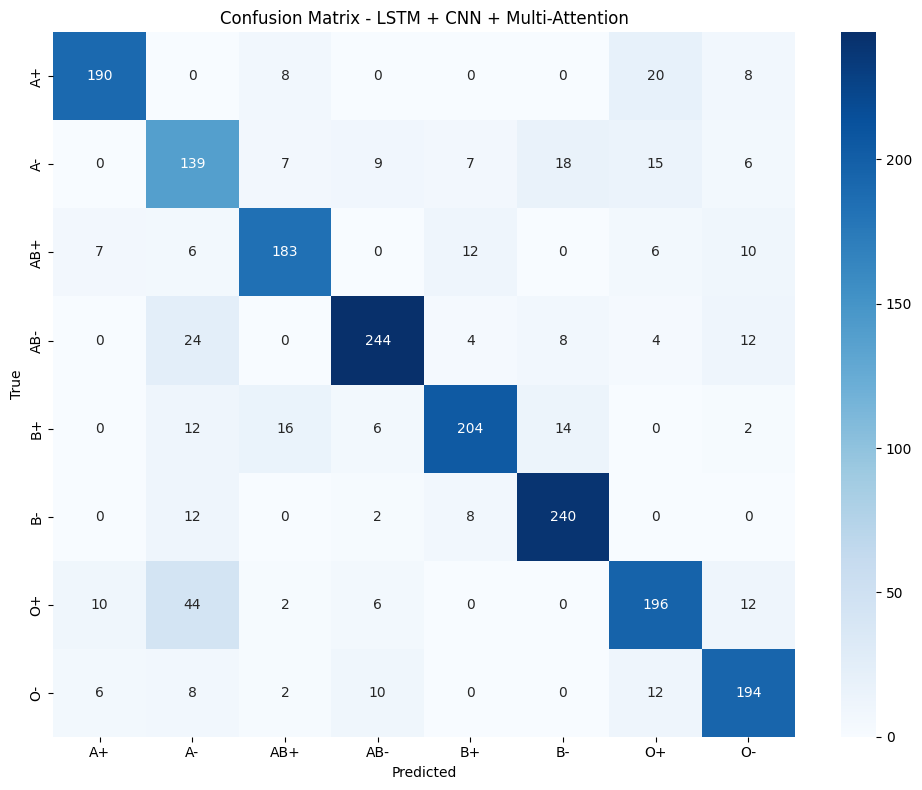

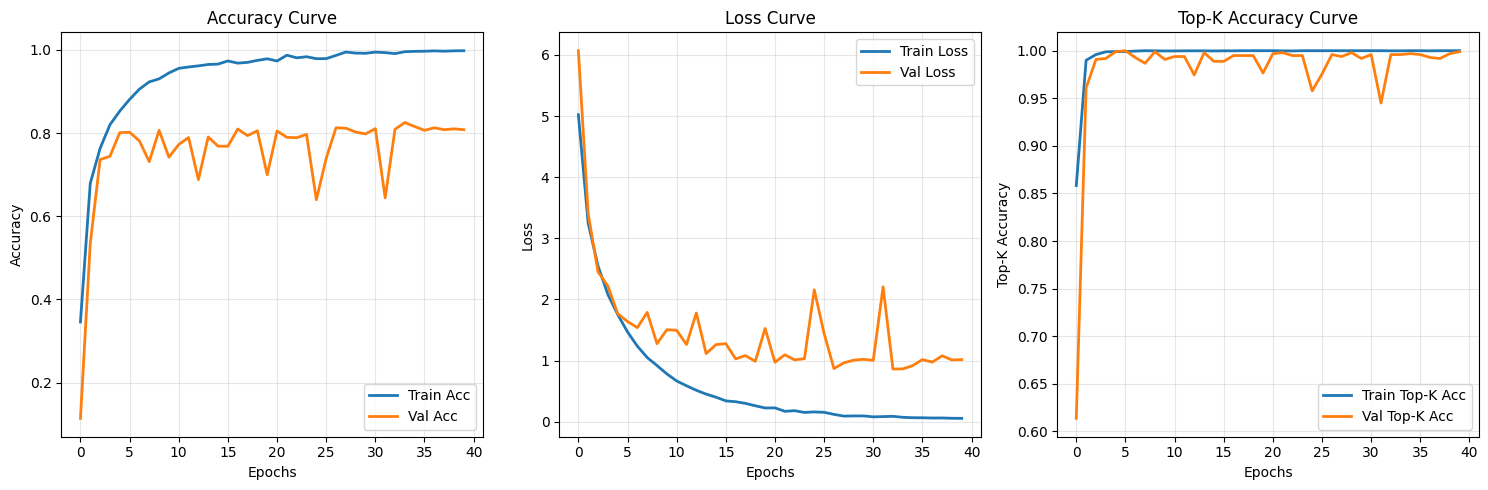

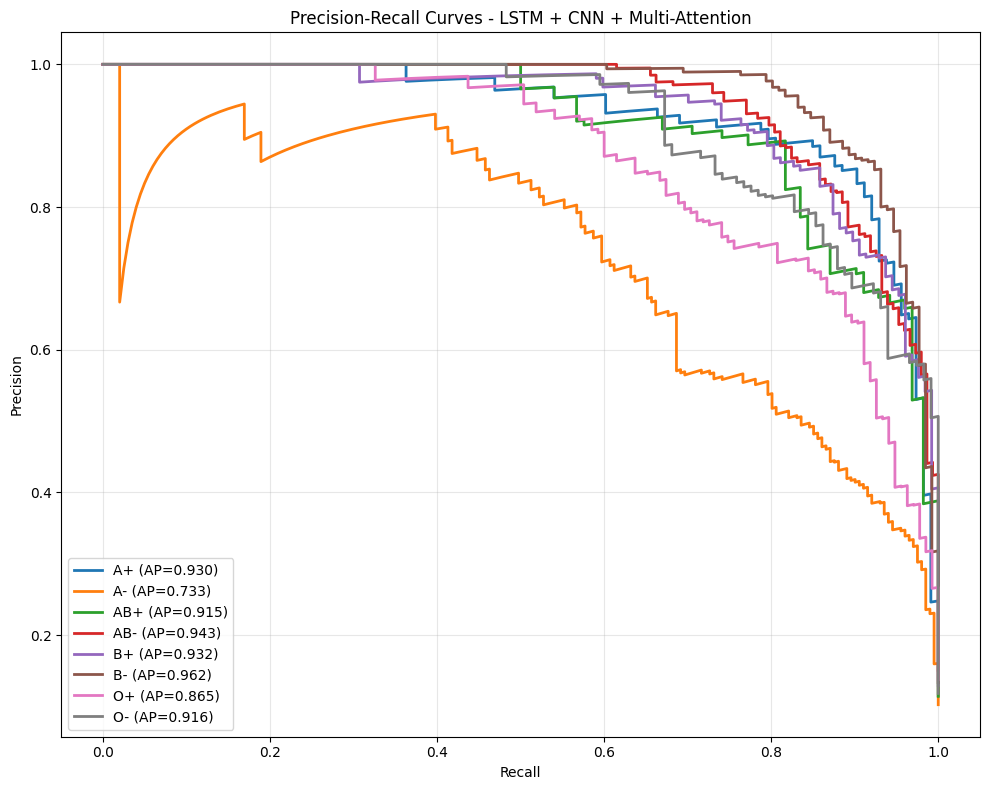

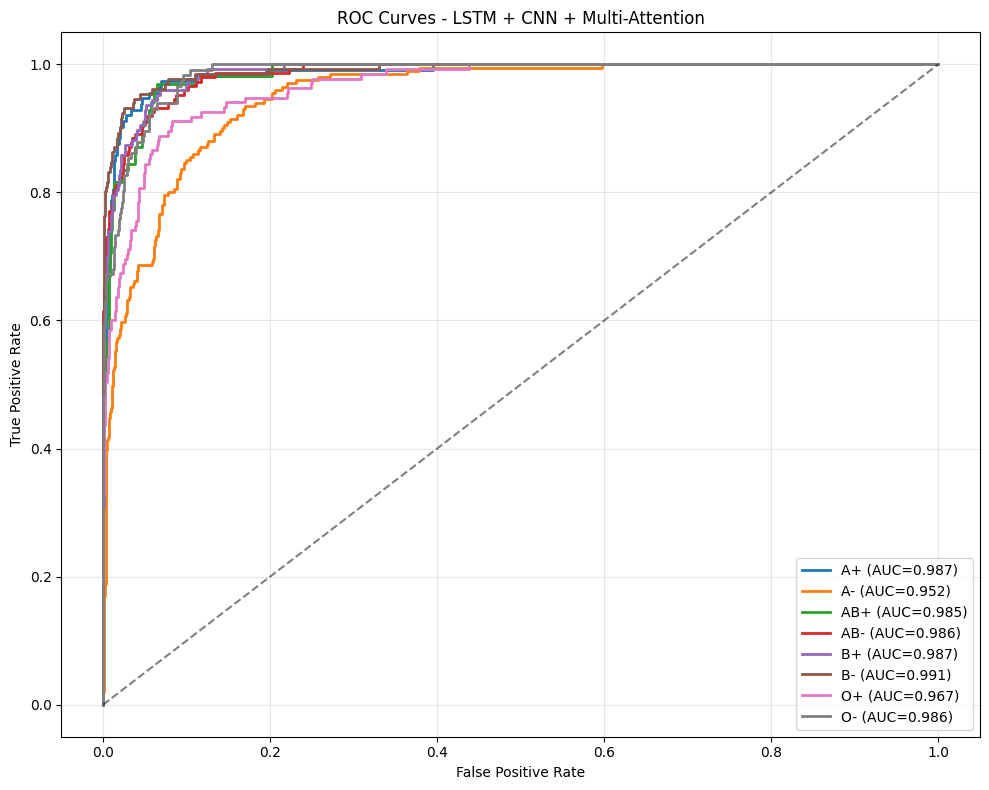

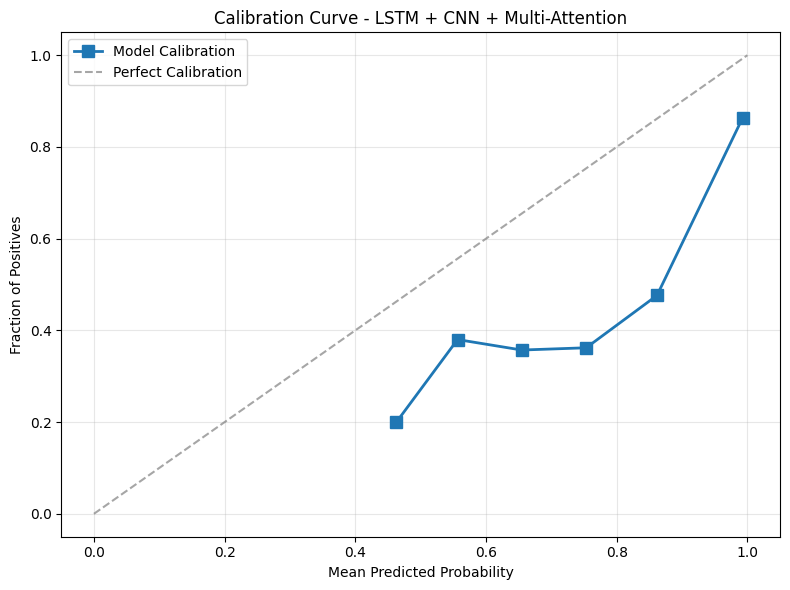


Brier Score: 0.1558

Total misclassified samples: 375 out of 1965 (19.1%)


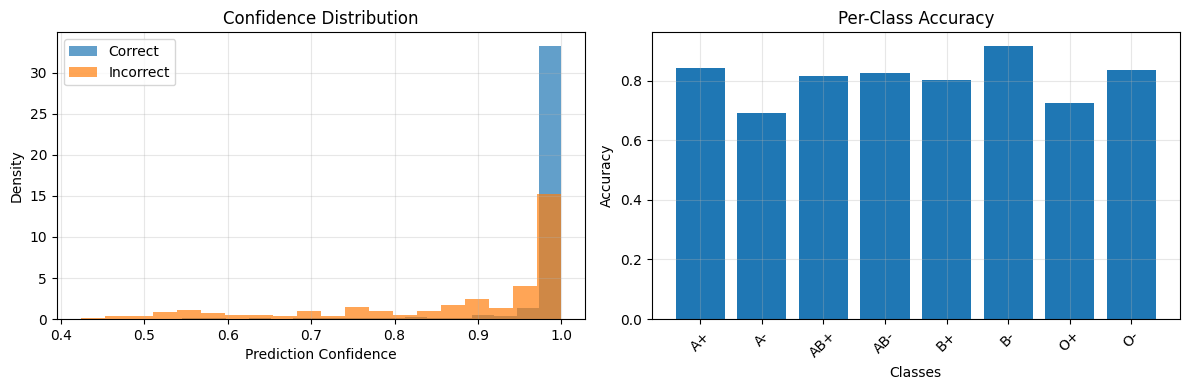


Sample misclassified images:


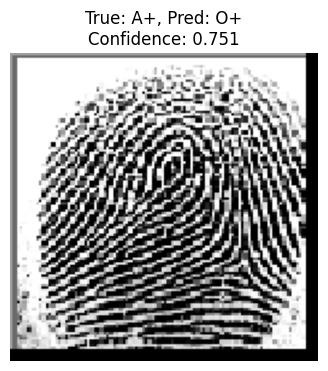

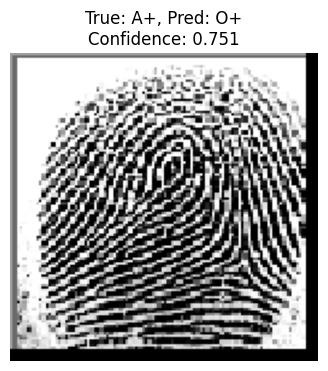

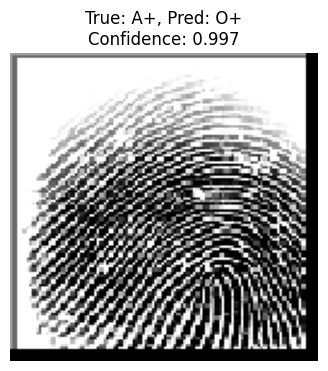

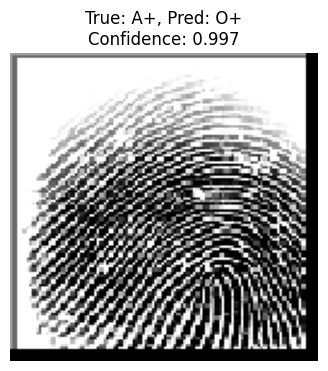

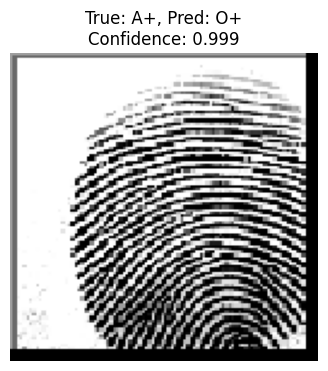

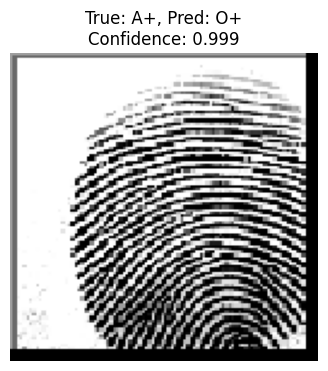

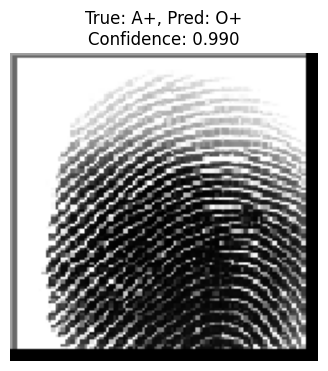

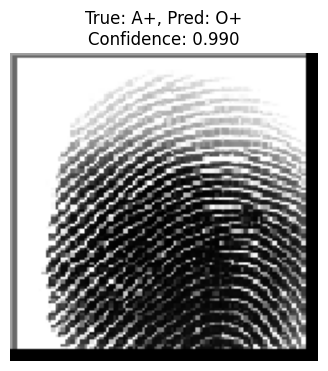

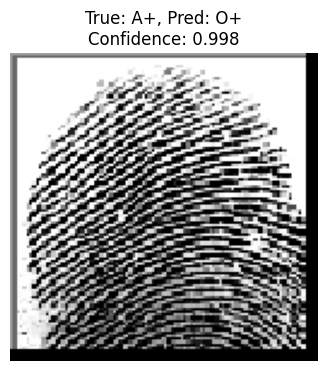

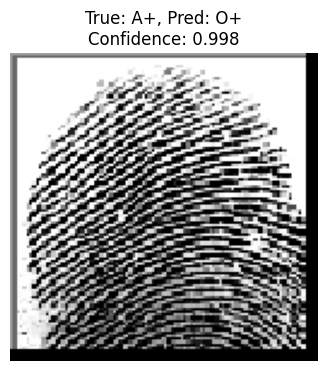


Model training completed successfully!
Final validation accuracy: 0.8081
Best validation accuracy: 0.8254


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers, regularizers
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_curve, average_precision_score,
                             roc_curve, auc, brier_score_loss)
from sklearn.calibration import calibration_curve

# -------------------------
# Dataset Path
# -------------------------
dataset_path = "/content/drive/MyDrive/dataset_blood_group"

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
img_size = (128, 128)
batch_size = 32

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

# -------------------------
# Multi-Attention Layers
# -------------------------
class SpatialAttentionLayer(layers.Layer):
    """Spatial attention mechanism for focusing on important regions"""
    def __init__(self, **kwargs):
        super(SpatialAttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.conv1 = layers.Conv2D(1, (7, 7), padding='same', activation='sigmoid')
        super(SpatialAttentionLayer, self).build(input_shape)

    def call(self, inputs):
        # Global average and max pooling across channels
        avg_pool = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        max_pool = tf.reduce_max(inputs, axis=-1, keepdims=True)

        # Concatenate and apply convolution
        concat = tf.concat([avg_pool, max_pool], axis=-1)
        attention_map = self.conv1(concat)

        return inputs * attention_map

class ChannelAttentionLayer(layers.Layer):
    """Channel attention mechanism for important feature channels"""
    def __init__(self, ratio=8, **kwargs):
        super(ChannelAttentionLayer, self).__init__(**kwargs)
        self.ratio = ratio

    def build(self, input_shape):
        self.channels = input_shape[-1]
        self.shared_dense1 = layers.Dense(self.channels // self.ratio, activation='relu')
        self.shared_dense2 = layers.Dense(self.channels, activation='sigmoid')
        self.global_avg_pool = layers.GlobalAveragePooling2D()
        self.global_max_pool = layers.GlobalMaxPooling2D()
        super(ChannelAttentionLayer, self).build(input_shape)

    def call(self, inputs):
        # Global average pooling
        avg_pool = self.global_avg_pool(inputs)
        avg_pool = layers.Reshape((1, 1, self.channels))(avg_pool)
        avg_pool = self.shared_dense1(avg_pool)
        avg_pool = self.shared_dense2(avg_pool)

        # Global max pooling
        max_pool = self.global_max_pool(inputs)
        max_pool = layers.Reshape((1, 1, self.channels))(max_pool)
        max_pool = self.shared_dense1(max_pool)
        max_pool = self.shared_dense2(max_pool)

        # Combine attention weights
        attention = avg_pool + max_pool
        return inputs * attention

class SelfAttentionLayer(layers.Layer):
    """Self-attention mechanism for sequence modeling"""
    def __init__(self, d_model, **kwargs):
        super(SelfAttentionLayer, self).__init__(**kwargs)
        self.d_model = d_model

    def build(self, input_shape):
        self.wq = layers.Dense(self.d_model)
        self.wk = layers.Dense(self.d_model)
        self.wv = layers.Dense(self.d_model)
        self.dense = layers.Dense(self.d_model)
        super(SelfAttentionLayer, self).build(input_shape)

    def call(self, inputs):
        q = self.wq(inputs)
        k = self.wk(inputs)
        v = self.wv(inputs)

        # Scaled dot-product attention
        matmul_qk = tf.matmul(q, k, transpose_b=True)
        dk = tf.cast(tf.shape(k)[-1], tf.float32)
        scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)

        attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)
        output = tf.matmul(attention_weights, v)

        return self.dense(output)

# -------------------------
# LSTM + CNN + Multi-Attention Model
# -------------------------
def build_lstm_cnn_attention_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    # CNN Feature Extraction with Channel Attention
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = ChannelAttentionLayer()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = ChannelAttentionLayer()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = SpatialAttentionLayer()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = SpatialAttentionLayer()(x)
    x = layers.GlobalAveragePooling2D()(x)

    # Reshape for LSTM (treat features as sequence)
    # We'll create artificial sequences by reshaping the features
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    # Create sequence dimension for LSTM
    x = layers.RepeatVector(8)(x)  # Create 8 time steps

    # Bidirectional LSTM with Self-Attention
    lstm_out = layers.Bidirectional(
        layers.LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.3)
    )(x)

    # Apply self-attention to LSTM outputs
    attention_out = SelfAttentionLayer(256)(lstm_out)

    # Global pooling and final classification
    x = layers.GlobalAveragePooling1D()(attention_out)
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model

# Alternative approach: Using CNN features as sequential input for LSTM
def build_cnn_lstm_sequence_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    # CNN feature extraction
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = ChannelAttentionLayer()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = SpatialAttentionLayer()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Reshape CNN output to sequences for LSTM
    # Each row of the feature map becomes a time step
    shape = tf.shape(x)
    x = layers.Reshape((shape[1] * shape[2], shape[3]))(x)  # (batch, seq_len, features)

    # Bidirectional LSTM with attention
    lstm_out = layers.Bidirectional(
        layers.LSTM(64, return_sequences=True, dropout=0.3)
    )(x)

    # Self-attention on LSTM outputs
    attention_out = SelfAttentionLayer(128)(lstm_out)

    # Global pooling and classification
    x = layers.GlobalMaxPooling1D()(attention_out)
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model

# Build the model
num_classes = len(train_data.class_indices)
print(f"Number of classes: {num_classes}")

# Choose which model architecture to use
model = build_lstm_cnn_attention_model((128, 128, 3), num_classes)
# model = build_cnn_lstm_sequence_model((128, 128, 3), num_classes)  # Alternative

# Print model summary
model.summary()

# Compile model with advanced optimizer settings
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4, beta_1=0.9, beta_2=0.999),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'top_k_categorical_accuracy']
)

# -------------------------
# Advanced Training with Callbacks
# -------------------------
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
]

# Train the model
print("Starting training...")
history = model.fit(
    train_data,
    epochs=40,
    validation_data=val_data,
    callbacks=callbacks,
    verbose=1
)

# -------------------------
# Evaluation
# -------------------------
print("Evaluating model...")
val_preds = model.predict(val_data, verbose=1)
y_pred = np.argmax(val_preds, axis=1)
y_true = val_data.classes
class_names = list(val_data.class_indices.keys())

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - LSTM + CNN + Multi-Attention")
plt.tight_layout()
plt.show()

# Training Curves
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'], label="Train Acc", linewidth=2)
plt.plot(history.history['val_accuracy'], label="Val Acc", linewidth=2)
plt.legend()
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(history.history['loss'], label="Train Loss", linewidth=2)
plt.plot(history.history['val_loss'], label="Val Loss", linewidth=2)
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(history.history['top_k_categorical_accuracy'], label="Train Top-K Acc", linewidth=2)
plt.plot(history.history['val_top_k_categorical_accuracy'], label="Val Top-K Acc", linewidth=2)
plt.legend()
plt.title("Top-K Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Top-K Accuracy")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# -------------------------
# Advanced Metrics
# -------------------------

# Precision-Recall Curves
plt.figure(figsize=(10, 8))
for i, class_name in enumerate(class_names):
    precision, recall, _ = precision_recall_curve((y_true == i).astype(int), val_preds[:, i])
    ap = average_precision_score((y_true == i).astype(int), val_preds[:, i])
    plt.plot(recall, precision, label=f"{class_name} (AP={ap:.3f})", linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves - LSTM + CNN + Multi-Attention")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ROC Curves
plt.figure(figsize=(10, 8))
for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve((y_true == i).astype(int), val_preds[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC={roc_auc:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - LSTM + CNN + Multi-Attention")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------
# Model Calibration Analysis
# -------------------------
probs_true = np.max(val_preds, axis=1)
y_binary = (y_true == y_pred).astype(int)
prob_true, prob_pred = calibration_curve(y_binary, probs_true, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, "s-", label="Model Calibration", linewidth=2, markersize=8)
plt.plot([0, 1], [0, 1], "--", color="gray", label="Perfect Calibration", alpha=0.7)
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve - LSTM + CNN + Multi-Attention")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

brier = brier_score_loss(y_binary, probs_true)
print(f"\nBrier Score: {brier:.4f}")

# -------------------------
# Error Analysis
# -------------------------
mis_idx = np.where(y_true != y_pred)[0]
print(f"\nTotal misclassified samples: {len(mis_idx)} out of {len(y_true)} ({len(mis_idx)/len(y_true)*100:.1f}%)")

# Show confidence distribution for correct vs incorrect predictions
correct_confidences = probs_true[y_true == y_pred]
incorrect_confidences = probs_true[y_true != y_pred]

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(correct_confidences, bins=20, alpha=0.7, label='Correct', density=True)
plt.hist(incorrect_confidences, bins=20, alpha=0.7, label='Incorrect', density=True)
plt.xlabel('Prediction Confidence')
plt.ylabel('Density')
plt.title('Confidence Distribution')
plt.legend()
plt.grid(True, alpha=0.3)

# Per-class accuracy
plt.subplot(1, 2, 2)
class_accuracies = []
for i, class_name in enumerate(class_names):
    class_mask = (y_true == i)
    class_acc = np.mean(y_pred[class_mask] == y_true[class_mask]) if np.sum(class_mask) > 0 else 0
    class_accuracies.append(class_acc)

plt.bar(range(len(class_names)), class_accuracies)
plt.xlabel('Classes')
plt.ylabel('Accuracy')
plt.title('Per-Class Accuracy')
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Display misclassified samples
print("\nSample misclassified images:")
for i, idx in enumerate(mis_idx[:10]):  # Show first 10
    batch_index = idx // val_data.batch_size
    index_in_batch = idx % val_data.batch_size

    img_batch, label_batch = val_data[batch_index]
    img = img_batch[index_in_batch]
    true_label = y_true[idx]
    pred_label = y_pred[idx]
    confidence = probs_true[idx]

    plt.figure(figsize=(6, 4))
    plt.imshow(img)
    plt.title(f"True: {class_names[true_label]}, Pred: {class_names[pred_label]}\nConfidence: {confidence:.3f}")
    plt.axis("off")
    plt.show()

print(f"\nModel training completed successfully!")
print(f"Final validation accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Best validation accuracy: {max(history.history['val_accuracy']):.4f}")